# 1. Introduction

This notebook trains a binary machine learning model to detect **Denial of Service (DoS)** traffic from two CSV datasets:

- `live_dos_current.csv` -> labeled as `1` (DoS attack)
- `live_non_ddos_current.csv` -> labeled as `0` (normal traffic)

The workflow is designed to be beginner-friendly while still following production-minded practices:

- chunked CSV loading for large files
- automatic numeric feature discovery
- heuristic removal of obvious identifier/timestamp columns
- missing value and infinite value handling
- feature engineering for `packets_per_second` when packet and duration columns are available
- tuned comparison of Random Forest, Logistic Regression, and K-Nearest Neighbors (KNN)
- model artifact saving for reuse in live inference

Because this is a **supervised binary classification** problem, the notebook adds **KNN classification** rather than unsupervised clustering. Hyperparameter tuning is performed on the training data only, and the final best model is selected using the untouched test split.


In [2]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "joblib": "joblib",
}

# Install the required libraries inside the active Jupyter kernel if any are missing.
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 200

RANDOM_STATE = 42
CHUNK_SIZE = 100_000
TARGET_COLUMN = "target"
DOS_PATH = Path("live_dos_current.csv")
NORMAL_PATH = Path("live_non_ddos_current.csv")
MODEL_OUTPUT_PATH = Path("dos_detection_model.joblib")

# Keep tuning computationally realistic for a 16 GB RAM machine.
MAX_TUNING_ROWS = 120_000
CV_FOLDS = 3
SEARCH_SCORING = "roc_auc"

for required_path in [DOS_PATH, NORMAL_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required dataset: {required_path.resolve()}")

print("Environment ready.")
print(f"DoS dataset: {DOS_PATH.resolve()}")
print(f"Normal dataset: {NORMAL_PATH.resolve()}")


Environment ready.
DoS dataset: C:\Users\anike\Downloads\Infodat_projects\live_dos_current.csv
Normal dataset: C:\Users\anike\Downloads\Infodat_projects\live_non_ddos_current.csv


# 2. Load Data

In this section we load both CSV files in chunks, assign the requested labels, merge them into a single dataset, and shuffle the rows so the training split does not depend on file order.


In [3]:
def read_labeled_csv(file_path: Path, label_value: int, chunk_size: int = CHUNK_SIZE) -> pd.DataFrame:
    """Read a potentially large CSV file in chunks and assign a consistent binary label."""
    chunks = []
    rows_loaded = 0

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        chunk[TARGET_COLUMN] = label_value
        chunk["source_file"] = file_path.name
        chunks.append(chunk)
        rows_loaded += len(chunk)
        print(f"Loaded {rows_loaded:,} rows from {file_path.name}")

    if not chunks:
        return pd.DataFrame(columns=[TARGET_COLUMN, "source_file"])

    return pd.concat(chunks, ignore_index=True)


def optimize_numeric_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to lower-memory dtypes where possible."""
    float_cols = df.select_dtypes(include=["float64"]).columns
    int_cols = df.select_dtypes(include=["int64"]).columns

    if len(float_cols) > 0:
        df[float_cols] = df[float_cols].apply(pd.to_numeric, downcast="float")
    if len(int_cols) > 0:
        df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast="integer")

    return df


dos_df = read_labeled_csv(DOS_PATH, label_value=1)
normal_df = read_labeled_csv(NORMAL_PATH, label_value=0)

raw_dataset = pd.concat([dos_df, normal_df], ignore_index=True)
raw_dataset = raw_dataset.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
raw_dataset = optimize_numeric_dtypes(raw_dataset)

print()
print(f"Merged dataset shape: {raw_dataset.shape}")
memory_mb = raw_dataset.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Approximate in-memory size: {memory_mb:,.2f} MB")
display(raw_dataset.head())


Loaded 100,000 rows from live_dos_current.csv
Loaded 200,000 rows from live_dos_current.csv
Loaded 251,491 rows from live_dos_current.csv
Loaded 100,000 rows from live_non_ddos_current.csv
Loaded 200,000 rows from live_non_ddos_current.csv
Loaded 246,090 rows from live_non_ddos_current.csv

Merged dataset shape: (497581, 51)
Approximate in-memory size: 317.71 MB


,srcip,dstip,sport,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,target,source_file
0,172.17.34.74,239.255.255.250,50996,1900,udp,INT,2.002296,654,0,1,0,0,0,-,326.625078,0.000000,3,0,0,0,0,0,218.00000,0.000000,0,0,0.000365,0.000000,1.776659e+09,1.776659e+09,1.001148,0.000000,0.0,0.0,0.0,0,8,0,0,0,2,9,9,2,1,1,1,Normal,0,0,live_non_ddos_current.csv
1,104.18.39.21,172.17.34.169,443,51129,tcp,CON,0.016713,134,82,53,128,0,0,https,8017.642454,4906.318516,2,1,18,253,569860042,3233010772,67.00000,82.000000,0,0,0.000000,0.000000,1.776620e+09,1.776620e+09,0.016713,0.000000,0.0,0.0,0.0,0,3,0,0,0,3,5,6,3,3,5,3,Normal,0,0,live_non_ddos_current.csv
2,192.168.254.13,192.168.254.30,59802,8080,tcp,CON,9.981417,906,8436,128,128,0,0,http,90.768674,845.170565,11,10,255,255,4458386,1842145681,82.36364,843.599976,0,0,2.975535,3.116558,1.776809e+09,1.776809e+09,0.998031,1.108880,0.0,0.0,0.0,0,27317,0,0,0,27373,27373,27377,27374,27373,4,27373,DoS,1,1,live_dos_current.csv
3,142.250.190.234,172.17.34.169,443,54782,udp,INT,0.006727,200,75,53,128,0,0,https,29733.130117,11149.923794,1,1,0,0,0,0,200.00000,75.000000,0,0,0.000000,0.000000,1.776652e+09,1.776652e+09,0.000000,0.000000,0.0,0.0,0.0,0,0,0,0,0,0,4,4,0,0,4,0,Normal,0,0,live_non_ddos_current.csv
4,192.168.254.13,192.168.254.30,53539,8080,tcp,CON,0.031711,480,4218,128,128,0,0,http,15136.768693,133014.354889,6,5,255,255,3643432756,1444373713,80.00000,843.599976,0,0,0.007796,0.007259,1.776809e+09,1.776809e+09,0.006342,0.007534,0.0,0.0,0.0,0,24093,0,0,0,24121,24122,24128,24121,24121,4,24121,DoS,1,1,live_dos_current.csv


# 3. Data Preprocessing

The preprocessing step is intentionally schema-aware instead of hard-coded. We:

- attempt to convert numeric-like text columns into numeric columns
- detect obvious non-useful columns such as labels, IP addresses, timestamps, and identifier fields
- keep the workflow generic so it can adapt to similar CSV schemas without relying on fixed feature names


In [4]:
def coerce_numeric_like_columns(
    df: pd.DataFrame,
    exclude_columns=None,
    success_threshold: float = 0.95,
) -> list:
    """Convert object columns to numeric when almost all non-null values are numeric-like."""
    exclude_columns = set(exclude_columns or [])
    converted_columns = []

    for col in df.columns:
        if col in exclude_columns or pd.api.types.is_numeric_dtype(df[col]):
            continue

        candidate = pd.to_numeric(df[col], errors="coerce")
        original_non_null = df[col].notna().sum()
        if original_non_null == 0:
            continue

        success_ratio = candidate.notna().sum() / original_non_null
        if success_ratio >= success_threshold:
            df[col] = candidate
            converted_columns.append(col)

    return converted_columns


def detect_non_useful_columns(columns) -> list:
    """Heuristically drop obvious identifiers, labels, and timestamp columns."""
    drop_columns = set()

    exact_name_matches = {
        "label",
        "attack_cat",
        "source_file",
        "srcip",
        "dstip",
        "src_ip",
        "dst_ip",
        "source_ip",
        "destination_ip",
        "stime",
        "ltime",
        "timestamp",
        "datetime",
        "date",
        "time",
        "flow_id",
        "id",
    }

    for col in columns:
        lower = col.strip().lower()

        if lower == TARGET_COLUMN:
            continue

        if lower in exact_name_matches:
            drop_columns.add(col)
            continue

        if lower.endswith("_id"):
            drop_columns.add(col)
            continue

        if any(token in lower for token in ["timestamp", "datetime", "epoch"]):
            drop_columns.add(col)
            continue

        if any(token in lower for token in ["ip_address", "ipv4", "ipv6"]):
            drop_columns.add(col)
            continue

    return sorted(drop_columns)


working_df = raw_dataset.copy()
converted_columns = coerce_numeric_like_columns(
    working_df,
    exclude_columns={TARGET_COLUMN, "source_file", "attack_cat"},
)
columns_to_drop = detect_non_useful_columns(working_df.columns)

print("Numeric-like columns converted:", converted_columns if converted_columns else "None")
print("Columns flagged as non-useful and removed later:", columns_to_drop if columns_to_drop else "None")


Numeric-like columns converted: None
Columns flagged as non-useful and removed later: ['attack_cat', 'dstip', 'label', 'ltime', 'source_file', 'srcip', 'stime']


# 4. Feature Engineering

Next we create the model-ready feature matrix.

- `packets_per_second` is created automatically when packet-count and duration columns can be inferred
- only numeric columns are kept for training
- missing values are filled with medians (falling back to `0` where needed)
- infinite values are replaced safely
- constant columns are removed because they do not help the model learn


In [5]:
def find_duration_column(columns) -> str | None:
    """Try to infer the duration column from common names."""
    preferred_names = ["duration", "dur", "flow_duration", "flow_dur"]
    lower_map = {str(col).lower(): col for col in columns}

    for candidate in preferred_names:
        if candidate in lower_map:
            return lower_map[candidate]

    for col in columns:
        lower = str(col).lower()
        if "duration" in lower or lower.endswith("_dur") or lower == "dur":
            return col

    return None


def infer_packet_count_series(df: pd.DataFrame):
    """Infer a packet-count series using common total or directional packet column names."""
    lower_map = {str(col).lower(): col for col in df.columns}

    total_candidates = [
        "packet_count",
        "packets",
        "total_packets",
        "pkt_count",
        "pkts",
    ]
    for candidate in total_candidates:
        if candidate in lower_map:
            column_name = lower_map[candidate]
            return pd.to_numeric(df[column_name], errors="coerce"), [column_name]

    directional_candidates = []
    for candidate in ["spkts", "src_pkts", "src_packets", "tot_fwd_pkts", "fwd_packets"]:
        if candidate in lower_map:
            directional_candidates.append(lower_map[candidate])
            break
    for candidate in ["dpkts", "dst_pkts", "dst_packets", "tot_bwd_pkts", "bwd_packets"]:
        if candidate in lower_map:
            directional_candidates.append(lower_map[candidate])
            break

    if len(directional_candidates) == 2:
        packet_series = sum(pd.to_numeric(df[col], errors="coerce") for col in directional_candidates)
        return packet_series, directional_candidates

    fuzzy_candidates = [
        col
        for col in df.columns
        if any(token in str(col).lower() for token in ["packet_count", "packets", "pkts"])
    ]
    if fuzzy_candidates:
        chosen = fuzzy_candidates[0]
        return pd.to_numeric(df[chosen], errors="coerce"), [chosen]

    return None, []


def add_packets_per_second(df: pd.DataFrame) -> dict:
    """Create packets_per_second when packet count and duration columns are available."""
    duration_col = find_duration_column(df.columns)
    packet_series, packet_columns = infer_packet_count_series(df)
    metadata = {
        "created": False,
        "duration_column": duration_col,
        "packet_columns": packet_columns,
    }

    if duration_col is None or packet_series is None:
        return metadata

    duration_series = pd.to_numeric(df[duration_col], errors="coerce").replace(0, np.nan)
    df["packets_per_second"] = (packet_series / duration_series).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    metadata["created"] = True
    return metadata


feature_info = add_packets_per_second(working_df)

y = working_df[TARGET_COLUMN].astype(np.int8).copy()

candidate_features = working_df.drop(columns=columns_to_drop + [TARGET_COLUMN], errors="ignore").copy()
numeric_columns = candidate_features.select_dtypes(include=[np.number]).columns.tolist()

X_raw = candidate_features[numeric_columns].copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

fill_values = X_raw.median(numeric_only=True)
fill_values = fill_values.replace([np.inf, -np.inf], np.nan).fillna(0)
X_raw = X_raw.fillna(fill_values).fillna(0)

constant_columns = [col for col in X_raw.columns if X_raw[col].nunique(dropna=False) <= 1]
if constant_columns:
    X_raw = X_raw.drop(columns=constant_columns)
    fill_values = fill_values.drop(labels=constant_columns, errors="ignore")

X_raw = X_raw.astype(np.float32)
fill_values = fill_values.astype(np.float32)
feature_columns = X_raw.columns.tolist()

print("Feature engineering metadata:")
print(feature_info)
print(f"Final modeling matrix shape: {X_raw.shape}")
print(f"Final numeric feature count: {len(feature_columns)}")
if constant_columns:
    print(f"Dropped constant columns: {constant_columns}")
display(X_raw.head())


Feature engineering metadata:
{'created': True, 'duration_column': 'dur', 'packet_columns': ['spkts', 'dpkts']}
Final modeling matrix shape: (497581, 30)
Final numeric feature count: 30
Dropped constant columns: ['sloss', 'dloss', 'trans_depth', 'res_bdy_len', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd']


,sport,dsport,dur,sbytes,dbytes,sttl,dttl,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,sjit,djit,sintpkt,dintpkt,ct_state_ttl,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,packets_per_second
0,50996.0,1900.0,2.002296,654.0,0.0,1.0,0.0,326.625092,0.000000,3.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,218.00000,0.000000,0.000365,0.000000,1.001148,0.000000,8.0,2.0,9.0,9.0,2.0,1.0,1.0,1.0,1.498280
1,443.0,51129.0,0.016713,134.0,82.0,53.0,128.0,8017.642578,4906.318359,2.0,1.0,18.0,253.0,5.698600e+08,3.233011e+09,67.00000,82.000000,0.000000,0.000000,0.016713,0.000000,3.0,3.0,5.0,6.0,3.0,3.0,5.0,3.0,179.499451
2,59802.0,8080.0,9.981417,906.0,8436.0,128.0,128.0,90.768677,845.170593,11.0,10.0,255.0,255.0,4.458386e+06,1.842146e+09,82.36364,843.599976,2.975535,3.116558,0.998031,1.108880,27317.0,27373.0,27373.0,27377.0,27374.0,27373.0,4.0,27373.0,2.103910
3,443.0,54782.0,0.006727,200.0,75.0,53.0,128.0,29733.130859,11149.923828,1.0,1.0,0.0,0.0,0.000000e+00,0.000000e+00,200.00000,75.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,4.0,4.0,0.0,0.0,4.0,0.0,297.331299
4,53539.0,8080.0,0.031711,480.0,4218.0,128.0,128.0,15136.768555,133014.359375,6.0,5.0,255.0,255.0,3.643433e+09,1.444374e+09,80.00000,843.599976,0.007796,0.007259,0.006342,0.007534,24093.0,24121.0,24122.0,24128.0,24121.0,24121.0,4.0,24121.0,346.884277


# 5. Exploratory Data Analysis

We now inspect the merged dataset, target balance, and feature relationships. For performance, the correlation heatmap uses at most a sample of `50,000` rows and focuses on the highest-variance numeric features.


Raw merged dataset shape: (497581, 51)
Model-ready feature matrix shape: (497581, 30)

Class distribution:


,count,percent
target,,
Normal (0),246090,49.46
DoS Attack (1),251491,50.54



Sample rows from the merged dataset:


,srcip,dstip,sport,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,target,source_file
0,172.17.34.74,239.255.255.250,50996,1900,udp,INT,2.002296,654,0,1,0,0,0,-,326.625078,0.000000,3,0,0,0,0,0,218.00000,0.000000,0,0,0.000365,0.000000,1.776659e+09,1.776659e+09,1.001148,0.000000,0.0,0.0,0.0,0,8,0,0,0,2,9,9,2,1,1,1,Normal,0,0,live_non_ddos_current.csv
1,104.18.39.21,172.17.34.169,443,51129,tcp,CON,0.016713,134,82,53,128,0,0,https,8017.642454,4906.318516,2,1,18,253,569860042,3233010772,67.00000,82.000000,0,0,0.000000,0.000000,1.776620e+09,1.776620e+09,0.016713,0.000000,0.0,0.0,0.0,0,3,0,0,0,3,5,6,3,3,5,3,Normal,0,0,live_non_ddos_current.csv
2,192.168.254.13,192.168.254.30,59802,8080,tcp,CON,9.981417,906,8436,128,128,0,0,http,90.768674,845.170565,11,10,255,255,4458386,1842145681,82.36364,843.599976,0,0,2.975535,3.116558,1.776809e+09,1.776809e+09,0.998031,1.108880,0.0,0.0,0.0,0,27317,0,0,0,27373,27373,27377,27374,27373,4,27373,DoS,1,1,live_dos_current.csv
3,142.250.190.234,172.17.34.169,443,54782,udp,INT,0.006727,200,75,53,128,0,0,https,29733.130117,11149.923794,1,1,0,0,0,0,200.00000,75.000000,0,0,0.000000,0.000000,1.776652e+09,1.776652e+09,0.000000,0.000000,0.0,0.0,0.0,0,0,0,0,0,0,4,4,0,0,4,0,Normal,0,0,live_non_ddos_current.csv
4,192.168.254.13,192.168.254.30,53539,8080,tcp,CON,0.031711,480,4218,128,128,0,0,http,15136.768693,133014.354889,6,5,255,255,3643432756,1444373713,80.00000,843.599976,0,0,0.007796,0.007259,1.776809e+09,1.776809e+09,0.006342,0.007534,0.0,0.0,0.0,0,24093,0,0,0,24121,24122,24128,24121,24121,4,24121,DoS,1,1,live_dos_current.csv


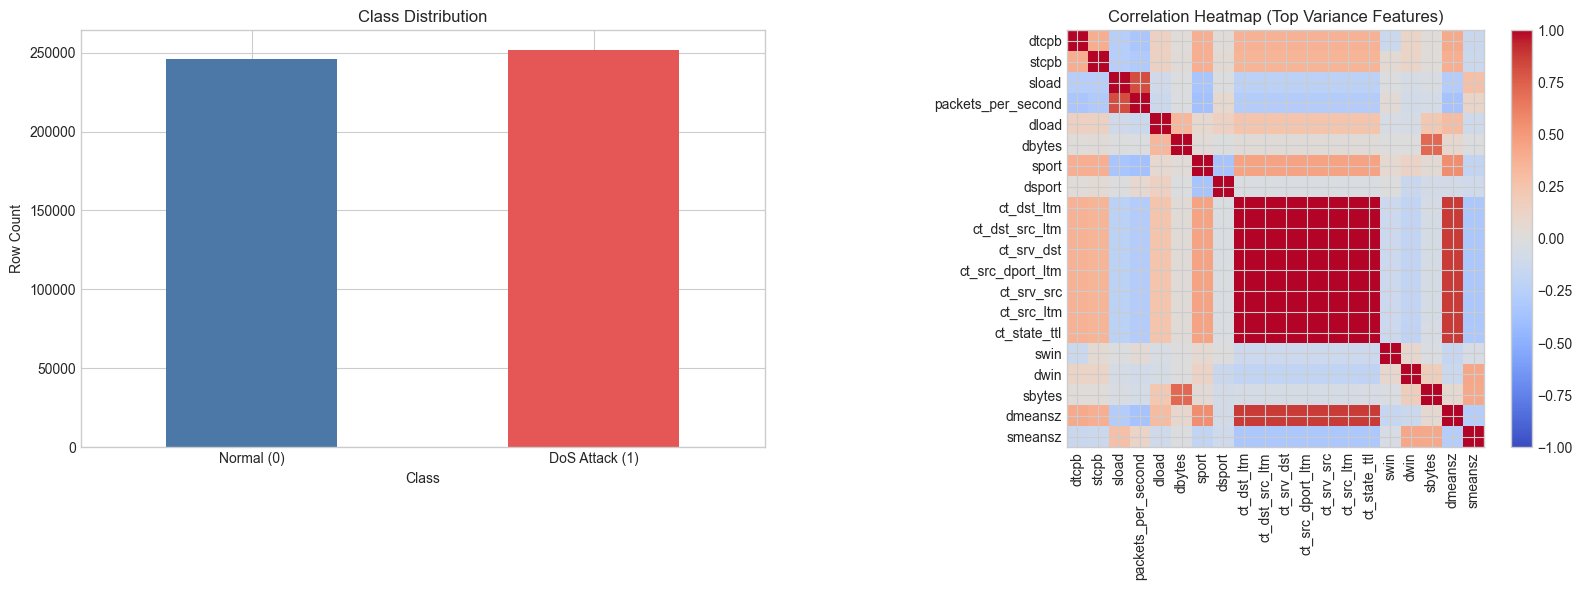

In [6]:
print(f"Raw merged dataset shape: {raw_dataset.shape}")
print(f"Model-ready feature matrix shape: {X_raw.shape}")
print()

class_distribution = y.value_counts().sort_index()
class_distribution.index = class_distribution.index.map({0: "Normal (0)", 1: "DoS Attack (1)"})
class_summary = pd.DataFrame(
    {
        "count": class_distribution,
        "percent": (class_distribution / len(y) * 100).round(2),
    }
)

print("Class distribution:")
display(class_summary)
print()
print("Sample rows from the merged dataset:")
display(raw_dataset.head())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_summary["count"].plot(kind="bar", ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Row Count")
axes[0].tick_params(axis="x", rotation=0)

sample_size = min(len(X_raw), 50_000)
corr_source = X_raw.sample(n=sample_size, random_state=RANDOM_STATE) if len(X_raw) > sample_size else X_raw
heatmap_features = corr_source.var().sort_values(ascending=False).head(min(20, corr_source.shape[1])).index.tolist()

if len(heatmap_features) >= 2:
    corr_matrix = corr_source[heatmap_features].corr()
    image = axes[1].imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title("Correlation Heatmap (Top Variance Features)")
    axes[1].set_xticks(range(len(heatmap_features)))
    axes[1].set_xticklabels(heatmap_features, rotation=90)
    axes[1].set_yticks(range(len(heatmap_features)))
    axes[1].set_yticklabels(heatmap_features)
    fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Not enough numeric features for a heatmap.", ha="center", va="center")

plt.tight_layout()
plt.show()


# 6. Model Training

We split the data into train and test sets using an 80/20 split, fit a `StandardScaler` on the training data only to avoid leakage, and then tune three classifiers:

- `RandomForestClassifier`
- `LogisticRegression`
- `KNeighborsClassifier (KNN)`

Hyperparameter tuning is performed with cross-validation on the training portion only. To keep the notebook practical on a 16 GB RAM machine, tuning uses a stratified subset of the training data when the full training set is very large.


In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

if len(X_train_raw) > MAX_TUNING_ROWS:
    tune_fraction = MAX_TUNING_ROWS / len(X_train_raw)
    X_tune_raw, _, y_tune, _ = train_test_split(
        X_train_raw,
        y_train,
        train_size=tune_fraction,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_tune_raw = X_train_raw.copy()
    y_tune = y_train.copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
X_tune = scaler.transform(X_tune_raw)

cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def run_hyperparameter_search(
    model_name: str,
    estimator,
    search_space: dict,
    X_search,
    y_search,
    search_type: str = "grid",
    n_iter: int | None = None,
) -> dict:
    """Tune model hyperparameters with cross-validation on the training split only."""
    search_kwargs = {
        "estimator": estimator,
        "scoring": SEARCH_SCORING,
        "cv": cv_strategy,
        "n_jobs": -1,
        "refit": True,
        "verbose": 1,
    }

    if search_type == "random":
        search = RandomizedSearchCV(
            param_distributions=search_space,
            n_iter=n_iter,
            random_state=RANDOM_STATE,
            **search_kwargs,
        )
    else:
        search = GridSearchCV(
            param_grid=search_space,
            **search_kwargs,
        )

    start_time = time.perf_counter()
    search.fit(X_search, y_search)
    tuning_time = time.perf_counter() - start_time

    print(f"\n{model_name} tuning finished in {tuning_time:.2f} seconds")
    print(f"Best cross-validation ROC-AUC: {search.best_score_:.4f}")
    print(f"Best hyperparameters: {search.best_params_}")

    return {
        "search": search,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_score": search.best_score_,
        "tuning_time_seconds": tuning_time,
    }


def fit_best_estimator_on_full_training(model_name: str, estimator, X_full_train, y_full_train) -> tuple:
    """Refit the tuned estimator on the full training split before holdout evaluation."""
    final_model = clone(estimator)
    start_time = time.perf_counter()
    final_model.fit(X_full_train, y_full_train)
    training_time = time.perf_counter() - start_time
    print(f"{model_name} refit on the full training split in {training_time:.2f} seconds")
    return final_model, training_time


def evaluate_model(model_name: str, trained_model, X_eval, y_eval, best_params: dict, best_cv_score: float, tuning_time: float, training_time: float) -> dict:
    """Evaluate a tuned model on the untouched test split."""

    y_pred = trained_model.predict(X_eval)
    if hasattr(trained_model, "predict_proba"):
        y_score = trained_model.predict_proba(X_eval)[:, 1]
    else:
        y_score = trained_model.predict(X_eval)

    return {
        "model": trained_model,
        "best_params": best_params,
        "best_cv_score": best_cv_score,
        "tuning_time_seconds": tuning_time,
        "training_time_seconds": training_time,
        "total_runtime_seconds": tuning_time + training_time,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_score),
        "confusion_matrix": confusion_matrix(y_eval, y_pred),
        "classification_report": classification_report(y_eval, y_pred, digits=4, zero_division=0),
        "y_pred": y_pred,
        "y_score": y_score,
    }


model_search_configs = {
    "RandomForestClassifier": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "search_type": "random",
        "n_iter": 12,
        "search_space": {
            "n_estimators": [150, 250, 350],
            "max_depth": [None, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"],
        },
    },
    "LogisticRegression": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
        "search_type": "grid",
        "search_space": {
            "C": [0.01, 0.1, 1.0, 5.0, 10.0],
            "penalty": ["l1", "l2"],
            "max_iter": [1000, 1500, 2000],
        },
    },
    "KNeighborsClassifier": {
        "estimator": KNeighborsClassifier(),
        "search_type": "grid",
        "search_space": {
            "n_neighbors": [5, 11, 21, 31],
            "weights": ["uniform", "distance"],
            "p": [1, 2],
            "leaf_size": [20, 30],
        },
    },
}

trained_models = {}
evaluation_results = {}
search_results = {}

print(f"Full training set shape: {X_train_raw.shape}")
print(f"Test set shape: {X_test_raw.shape}")
print(f"Tuning subset shape: {X_tune_raw.shape}")

for model_name, config in model_search_configs.items():
    print("\n" + "#" * 100)
    print(f"Tuning {model_name}")
    print("#" * 100)

    search_result = run_hyperparameter_search(
        model_name=model_name,
        estimator=config["estimator"],
        search_space=config["search_space"],
        X_search=X_tune,
        y_search=y_tune,
        search_type=config.get("search_type", "grid"),
        n_iter=config.get("n_iter"),
    )
    search_results[model_name] = search_result

    final_model, training_time = fit_best_estimator_on_full_training(
        model_name=model_name,
        estimator=search_result["best_estimator"],
        X_full_train=X_train,
        y_full_train=y_train,
    )

    evaluation_results[model_name] = evaluate_model(
        model_name=model_name,
        trained_model=final_model,
        X_eval=X_test,
        y_eval=y_test,
        best_params=search_result["best_params"],
        best_cv_score=search_result["best_cv_score"],
        tuning_time=search_result["tuning_time_seconds"],
        training_time=training_time,
    )
    trained_models[model_name] = final_model


Full training set shape: (398064, 30)
Test set shape: (99517, 30)
Tuning subset shape: (119999, 30)

####################################################################################################
Tuning RandomForestClassifier
####################################################################################################
Fitting 3 folds for each of 12 candidates, totalling 36 fits

RandomForestClassifier tuning finished in 162.13 seconds
Best cross-validation ROC-AUC: 1.0000
Best hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
RandomForestClassifier refit on the full training split in 30.30 seconds

####################################################################################################
Tuning LogisticRegression
####################################################################################################
Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\Users\anike\Downloads\Attack datasets\rogueshield311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



LogisticRegression tuning finished in 38.16 seconds
Best cross-validation ROC-AUC: 0.9996
Best hyperparameters: {'C': 1.0, 'max_iter': 1000, 'penalty': 'l2'}


c:\Users\anike\Downloads\Attack datasets\rogueshield311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


LogisticRegression refit on the full training split in 10.89 seconds

####################################################################################################
Tuning KNeighborsClassifier
####################################################################################################
Fitting 3 folds for each of 32 candidates, totalling 96 fits

KNeighborsClassifier tuning finished in 707.47 seconds
Best cross-validation ROC-AUC: 0.9997
Best hyperparameters: {'leaf_size': 20, 'n_neighbors': 31, 'p': 2, 'weights': 'distance'}
KNeighborsClassifier refit on the full training split in 0.05 seconds


# 7. Evaluation

This section compares all tuned models using:

- best cross-validation ROC-AUC from tuning
- accuracy
- precision
- recall
- F1-score
- confusion matrix
- ROC-AUC score on the untouched test set
- full `classification_report`

The final winner is the model with the best **test ROC-AUC**, using F1-score and recall as tie-breakers. The notebook also prints the best hyperparameters discovered during tuning.


Evaluation summary:


,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,tuning_time_seconds,final_fit_time_seconds,total_runtime_seconds,best_params
model,,,,,,,,,,
RandomForestClassifier,1.0000,0.9998,1.0000,0.9996,0.9998,1.0000,162.1277,30.3004,192.4281,"{'n_estimators': 250, 'min_samples_split': 5, ..."
KNeighborsClassifier,0.9997,0.9994,0.9999,0.9989,0.9994,0.9999,707.4700,0.0543,707.5243,"{'leaf_size': 20, 'n_neighbors': 31, 'p': 2, '..."
LogisticRegression,0.9996,0.9992,0.9997,0.9987,0.9992,0.9997,38.1643,10.8874,49.0516,"{'C': 1.0, 'max_iter': 1000, 'penalty': 'l2'}"



Overall best model on the test split: RandomForestClassifier
Best hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Best test ROC-AUC: 1.0000
Best test F1-score: 0.9998

RandomForestClassifier classification report
Best hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     49218
           1     1.0000    0.9996    0.9998     50299

    accuracy                         0.9998     99517
   macro avg     0.9998    0.9998    0.9998     99517
weighted avg     0.9998    0.9998    0.9998     99517


LogisticRegression classification report
Best hyperparameters: {'C': 1.0, 'max_iter': 1000, 'penalty': 'l2'}
              precision    recall  f1-score   support

           0     0.9987    0.9997    0.9992     49218
           1     0.9997    0.

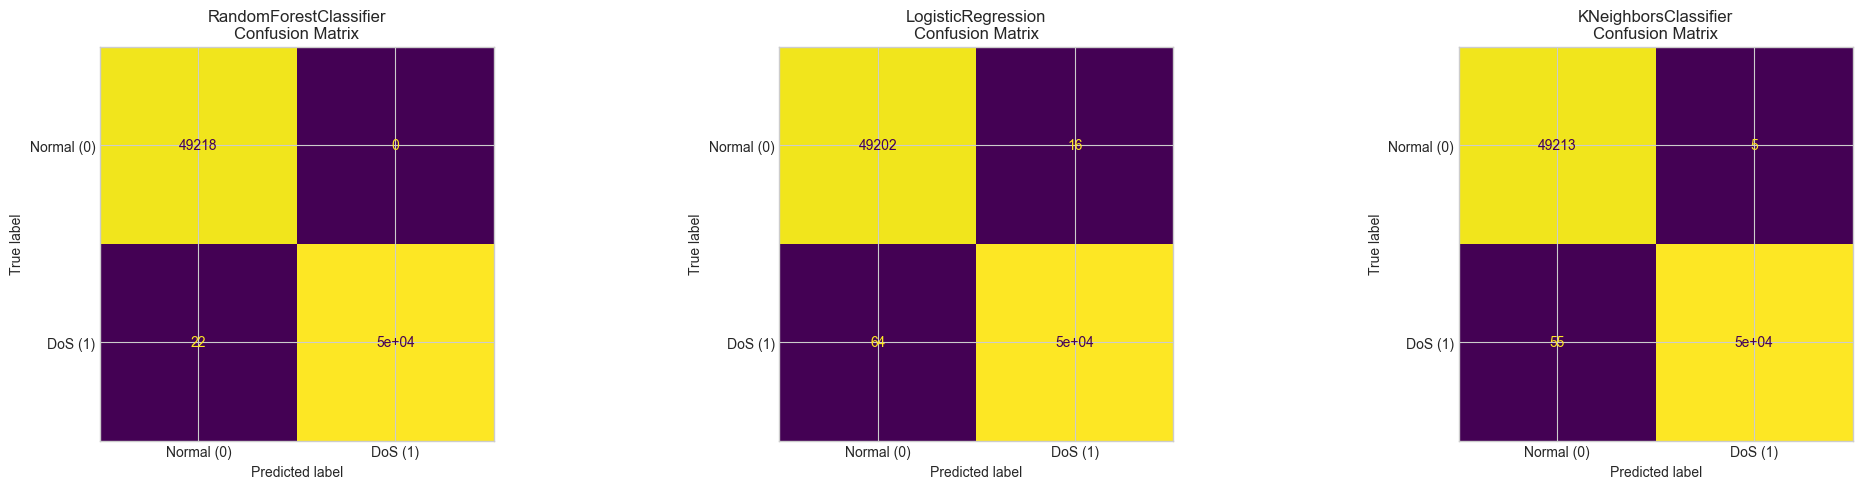

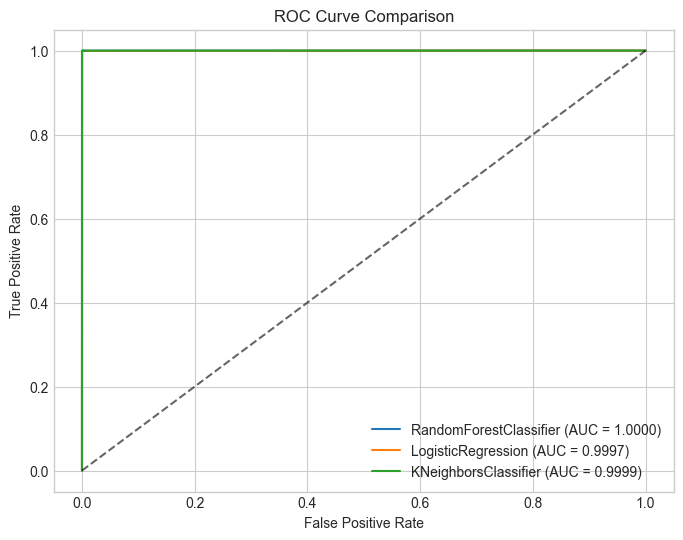

In [8]:
summary_rows = []
for model_name, result in evaluation_results.items():
    summary_rows.append(
        {
            "model": model_name,
            "best_cv_roc_auc": result["best_cv_score"],
            "test_accuracy": result["accuracy"],
            "test_precision": result["precision"],
            "test_recall": result["recall"],
            "test_f1": result["f1"],
            "test_roc_auc": result["roc_auc"],
            "tuning_time_seconds": result["tuning_time_seconds"],
            "final_fit_time_seconds": result["training_time_seconds"],
            "total_runtime_seconds": result["total_runtime_seconds"],
            "best_params": str(result["best_params"]),
        }
    )

evaluation_df = pd.DataFrame(summary_rows).set_index("model")
evaluation_df = evaluation_df.sort_values(
    ["test_roc_auc", "test_f1", "test_recall"],
    ascending=False,
)

print("Evaluation summary:")
display(evaluation_df.round(4))

best_model_name = evaluation_df.index[0]
best_result = evaluation_results[best_model_name]

print()
print("Overall best model on the test split:", best_model_name)
print("Best hyperparameters:", best_result["best_params"])
print(f"Best test ROC-AUC: {best_result['roc_auc']:.4f}")
print(f"Best test F1-score: {best_result['f1']:.4f}")

for model_name, result in evaluation_results.items():
    print()
    print("=" * 100)
    print(f"{model_name} classification report")
    print("=" * 100)
    print("Best hyperparameters:", result["best_params"])
    print(result["classification_report"])

fig, axes = plt.subplots(1, len(evaluation_results), figsize=(7 * len(evaluation_results), 5))
if len(evaluation_results) == 1:
    axes = [axes]

for ax, (model_name, result) in zip(axes, evaluation_results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=["Normal (0)", "DoS (1)"],
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name}\nConfusion Matrix")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, result in evaluation_results.items():
    fpr, tpr, _ = roc_curve(y_test, result["y_score"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {result['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


# 8. Model Saving

The best-performing tuned model is saved as `dos_detection_model.joblib` together with the scaler, preprocessing metadata, tuning summary, and the winning hyperparameters so the same setup can be reused later in production or live monitoring.


In [9]:
best_model = trained_models[best_model_name]

model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "scaler": scaler,
    "feature_columns": feature_columns,
    "fill_values": fill_values.to_dict(),
    "non_useful_columns": columns_to_drop,
    "converted_numeric_like_columns": converted_columns,
    "engineered_feature_info": feature_info,
    "random_state": RANDOM_STATE,
    "best_params": evaluation_results[best_model_name]["best_params"],
    "best_cv_score": evaluation_results[best_model_name]["best_cv_score"],
    "metrics": evaluation_df.to_dict(orient="index"),
    "target_mapping": {"normal": 0, "dos": 1},
    "source_files": {
        "dos_dataset": str(DOS_PATH.resolve()),
        "normal_dataset": str(NORMAL_PATH.resolve()),
    },
    "tuning_configuration": {
        "max_tuning_rows": MAX_TUNING_ROWS,
        "cv_folds": CV_FOLDS,
        "search_scoring": SEARCH_SCORING,
    },
    "saved_at_utc": pd.Timestamp.utcnow().isoformat(),
}

joblib.dump(model_artifact, MODEL_OUTPUT_PATH)

print(f"Best model selected by test ROC-AUC: {best_model_name}")
print(f"Winning hyperparameters: {evaluation_results[best_model_name]['best_params']}")
print(f"Saved model artifact to: {MODEL_OUTPUT_PATH.resolve()}")


Best model selected by test ROC-AUC: RandomForestClassifier
Winning hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Saved model artifact to: C:\Users\anike\Downloads\Infodat_projects\dos_detection_model.joblib


C:\Users\anike\AppData\Local\Temp\ipykernel_27792\3500560073.py:26: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "saved_at_utc": pd.Timestamp.utcnow().isoformat(),


# 9. Live Prediction Demo

The final cell demonstrates how to take one sample row, apply the same preprocessing logic, run inference with the saved artifact, and print a human-readable result.


Sample input row used for inference:


,srcip,dstip,sport,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,source_file
25685,192.168.254.13,192.168.254.30,56145,8080,tcp,CON,10.240653,960,8436,128,128,0,0,http,93.744024,823.775609,12,10,255,255,718276829,183536708,80.0,843.599976,0,0,2.923924,3.195616,1.776809e+09,1.776809e+09,0.930968,1.13746,0.0,0.0,0.0,0,27265,0,0,0,27313,27313,27318,27314,27313,1,27313,DoS,1,live_dos_current.csv


Predicted class: 1
DoS Attack Detected
Winning model: RandomForestClassifier
Winning hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
